## Imports


In [1]:
from datasets import load_dataset
from preprocess import preprocess
from NaiveBayes.naivebayes import NaiveBayes
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score , precision_score , recall_score, f1_score , confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from metrics import precision_recall_f1 , confusion_matrix as scratch_confusion_matrix



## Load Dataset


In [2]:
dataset = load_dataset("ag_news")

# shuffle the dataset to ensure that the train and test sets are not ordered in any way
dataset = dataset.shuffle(seed=42)

# split the dataset into train and test sets
train_data = dataset["train"]
test_data = dataset["test"]

print(f"Train size: {len(train_data)}")
print(f"Test size: {len(test_data)}")

print(dataset["test"]["text"][:3])   # first 3 texts
print(dataset["train"][1])
print(dataset["train"][1]["text"])

dataset["train"].to_pandas().head(10)

Train size: 120000
Test size: 7600
['Indian board plans own telecast of Australia series The Indian cricket board said on Wednesday it was making arrangements on its own to broadcast next month #39;s test series against Australia, which is under threat because of a raging TV rights dispute.', 'Stocks Higher on Drop in Jobless Claims A sharp drop in initial unemployment claims and bullish forecasts from Nokia and Texas Instruments sent stocks slightly higher in early trading Thursday.', 'Nuggets 112, Raptors 106 Carmelo Anthony scored 30 points and Kenyon Martin added 24 points and 16 rebounds, helping the Denver Nuggets hold off the Toronto Raptors 112-106 Wednesday night.']
{'text': 'Desiring Stability Redskins coach Joe Gibbs expects few major personnel changes in the offseason and wants to instill a culture of stability in Washington.', 'label': 1}
Desiring Stability Redskins coach Joe Gibbs expects few major personnel changes in the offseason and wants to instill a culture of stabi

,text,label
0,Bangladesh paralysed by strikes Opposition act...,0
1,Desiring Stability Redskins coach Joe Gibbs ex...,1
2,Will Putin #39;s Power Play Make Russia Safer?...,0
3,U2 pitches for Apple New iTunes ads airing dur...,3
4,S African TV in beheading blunder Public broad...,0
5,A Cosmic Storm: When Galaxy Clusters Collide A...,3
6,West sets deadline for Iran to freeze uranium ...,0
7,Computer Assoc. Cuts 800 Jobs Worldwide (AP) A...,3
8,CA Opens Utility Pricing for Mainframes Keepin...,3
9,Economy builds steam in KC Fed district The ec...,2


## Preprocess Data 

In [3]:
x_train = [preprocess(x) for x in train_data["text"]]
y_train = train_data["label"]

x_test = [preprocess(x) for x in test_data["text"]]
y_test = test_data["label"]

print(x_train[:3])
print(y_train[:3])


[['bangladesh', 'paralysed', 'by', 'strikes', 'opposition', 'activists', 'have', 'brought', 'many', 'towns', 'and', 'cities', 'in', 'bangladesh', 'to', 'a', 'halt', 'the', 'day', 'after', '18', 'people', 'died', 'in', 'explosions', 'at', 'a', 'political', 'rally'], ['desiring', 'stability', 'redskins', 'coach', 'joe', 'gibbs', 'expects', 'few', 'major', 'personnel', 'changes', 'in', 'the', 'offseason', 'and', 'wants', 'to', 'instill', 'a', 'culture', 'of', 'stability', 'in', 'washington'], ['will', 'putin', '39s', 'power', 'play', 'make', 'russia', 'safer', 'outwardly', 'russia', 'has', 'not', 'changed', 'since', 'the', 'barrage', 'of', 'terrorist', 'attacks', 'that', 'culminated', 'in', 'the', 'school', 'massacre', 'in', 'beslan', 'on', 'sept']]
[0, 1, 0]


# Train the Manual Naive Bayes

In [4]:
model = NaiveBayes()
model.fit(x_train, y_train)

preds = model.predict(x_test)

## Evaluation for the Manual Model

Scratch NB Accuracy: 90.145
Scratch NB Precision: 90.106
Scratch NB Recall: 90.145
Scratch NB F1: 90.113


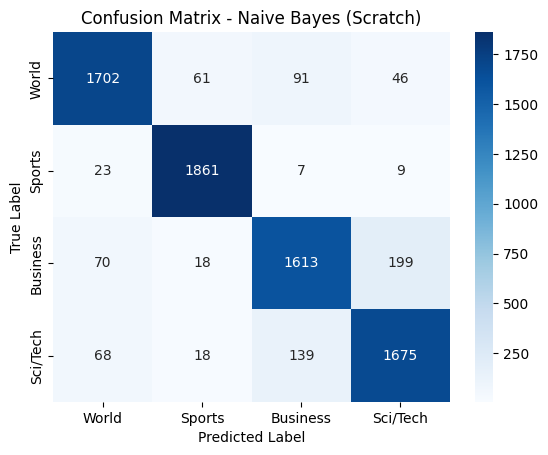

In [5]:
# Evaluation Metrics
manual_accuracy = accuracy_score(y_test, preds) * 100   
manual_precision = precision_score(y_test, preds, average='macro') * 100
manual_recall = recall_score(y_test, preds, average='macro') * 100
manual_f1 = f1_score(y_test, preds, average='macro') * 100

print(f"Scratch NB Accuracy: {manual_accuracy:.3f}")
print(f"Scratch NB Precision: {manual_precision:.3f}")
print(f"Scratch NB Recall: {manual_recall:.3f}")
print(f"Scratch NB F1: {manual_f1:.3f}")

# Confusion Matrix
labels = ["World", "Sports", "Business", "Sci/Tech"]
cm_manual = confusion_matrix(y_test, preds)

sns.heatmap(
    cm_manual,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Naive Bayes (Scratch)')
plt.show()
plt.show()  


## SKlearn Model


In [6]:
vectorizer = CountVectorizer(lowercase=True, stop_words=None)

X_train_vec = vectorizer.fit_transform(train_data["text"])
X_test_vec = vectorizer.transform(test_data["text"])

clf = MultinomialNB()
clf.fit(X_train_vec, y_train)

sklearn_preds = clf.predict(X_test_vec)

## Evaluation for the SKLearn Model

Sklearn NB Accuracy: 90.092
Sklearn NB Precision: 90.056
Sklearn NB Recall: 90.092
Sklearn NB F1: 90.055


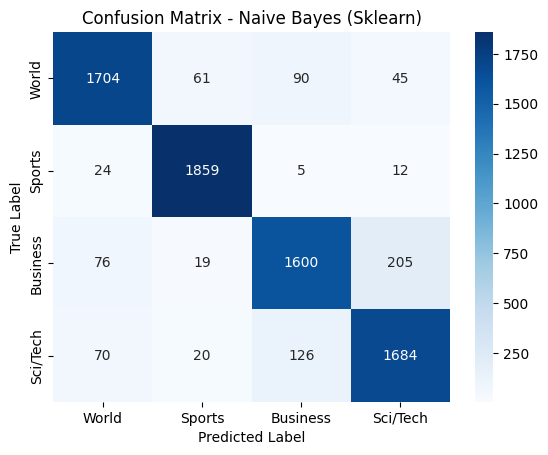

In [7]:
# Evaluation Metrics
sklearn_accuracy = accuracy_score(y_test, sklearn_preds) * 100
sklearn_precision = precision_score(y_test, sklearn_preds, average='macro') * 100   
sklearn_recall = recall_score(y_test, sklearn_preds, average='macro') * 100
sklearn_f1 = f1_score(y_test, sklearn_preds, average='macro') * 100

print(f"Sklearn NB Accuracy: {sklearn_accuracy:.3f}")
print(f"Sklearn NB Precision: {sklearn_precision:.3f}")
print(f"Sklearn NB Recall: {sklearn_recall:.3f}")
print(f"Sklearn NB F1: {sklearn_f1:.3f}")

# Confusion Matrix
cm_sklearn = confusion_matrix(y_test, sklearn_preds)
sns.heatmap(
    cm_sklearn,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Naive Bayes (Sklearn)')
plt.show()


## Comparison between SKLearn Evaluation metrics and From-Scratch Implemented metrics

In [10]:
def compare_with_sklearn(
    y_test: np.ndarray, preds: np.ndarray, model_name: str = "Model"
):
    """
    Run both the from-scratch and sklearn metrics on the same
    (y_true, y_pred) pair and print a side-by-side comparison.

    """
    cm_ours, classes = scratch_confusion_matrix(y_test, preds)
    metrics_ours = precision_recall_f1(cm_ours)

    cm_sk = confusion_matrix(y_test, preds)
    labels = sorted(np.unique(y_test))

    prec_sk_per = precision_score(
        y_test, preds, labels=labels, average=None, zero_division=0
    )
    rec_sk_per = recall_score(
        y_test, preds, labels=labels, average=None, zero_division=0
    )
    f1_sk_per = f1_score(y_test, preds, labels=labels, average=None, zero_division=0)
    prec_sk_mac = precision_score(y_test, preds, average="macro", zero_division=0)
    rec_sk_mac = recall_score(y_test, preds, average="macro", zero_division=0)
    f1_sk_mac = f1_score(y_test, preds, average="macro", zero_division=0)

    sep = "=" * 65
    print(f"\n{sep}")
    print(f"  {model_name}")
    print(sep)

    print("\n── CONFUSION MATRIX ──")
    print(f"Classes: {classes.tolist()}\n")
    print("Ours:")
    print(cm_ours)
    print("\nScikit-learn:")
    print(cm_sk)
    print("\nMatrices match:", np.array_equal(cm_ours, cm_sk))

    print("\n── PER-CLASS METRICS ──")
    header = (
        f"{'Class':<8} {'Prec (ours)':>12} {'Prec (sk)':>10} "
        f"{'Rec (ours)':>11} {'Rec (sk)':>9} {'F1 (ours)':>10} {'F1 (sk)':>8}"
    )
    print(header)
    print("-" * len(header))
    for i, cls in enumerate(classes):
        print(
            f"{cls:<8} "
            f"{metrics_ours['precision_per_class'][i]:>12.4f} "
            f"{prec_sk_per[i]:>10.4f} "
            f"{metrics_ours['recall_per_class'][i]:>11.4f} "
            f"{rec_sk_per[i]:>9.4f} "
            f"{metrics_ours['f1_per_class'][i]:>10.4f} "
            f"{f1_sk_per[i]:>8.4f}"
        )

    print("\n── MACRO-AVERAGED METRICS ──")
    print(f"{'Metric':<12} {'Ours':>10} {'Scikit-learn':>14} {'Match':>8}")
    print("-" * 48)
    for name, ours_val, sk_val in [
        ("Precision", metrics_ours["precision_macro"], prec_sk_mac),
        ("Recall", metrics_ours["recall_macro"], rec_sk_mac),
        ("F1-score", metrics_ours["f1_macro"], f1_sk_mac),
    ]:
        match = np.isclose(ours_val, sk_val, atol=1e-9)
        print(f"{name:<12} {ours_val:>10.6f} {sk_val:>14.6f} {str(match):>8}")
    print()


# Print Comparison
compare_with_sklearn(y_test, preds, model_name="Naive Bayes (Scratch)")      


  Naive Bayes (Scratch)

── CONFUSION MATRIX ──
Classes: [0, 1, 2, 3]

Ours:
[[1702   61   91   46]
 [  23 1861    7    9]
 [  70   18 1613  199]
 [  68   18  139 1675]]

Scikit-learn:
[[1702   61   91   46]
 [  23 1861    7    9]
 [  70   18 1613  199]
 [  68   18  139 1675]]

Matrices match: True

── PER-CLASS METRICS ──
Class     Prec (ours)  Prec (sk)  Rec (ours)  Rec (sk)  F1 (ours)  F1 (sk)
--------------------------------------------------------------------------
0              0.9136     0.9136      0.8958    0.8958     0.9046   0.9046
1              0.9505     0.9505      0.9795    0.9795     0.9647   0.9647
2              0.8719     0.8719      0.8489    0.8489     0.8603   0.8603
3              0.8683     0.8683      0.8816    0.8816     0.8749   0.8749

── MACRO-AVERAGED METRICS ──
Metric             Ours   Scikit-learn    Match
------------------------------------------------
Precision      0.901064       0.901064     True
Recall         0.901447       0.901447     True
F